# 03. Curated neutron-elastic data and the global windowed LROM

This notebook is a transparent audit of the current global workflow.
It loads the vendored KDUQ fit corpus and post-KD held-out corpus,
overlays every retained angular distribution with the unmodified
Koning--Delaroche (KD) prediction, and validates the distributed
three-window ridge LROM against the independent FOM.

The black curve is always the current KD FOM. The dashed orange curve
is the hard-routed LROM evaluated at the same KD parameters. Data points
retain their reported statistical uncertainties. No calibration is
performed here: this notebook establishes the baseline to which future
MAP and posterior calculations must be compared.

## Model and data provenance

The data in `data/curated` are an unmodified subset of
`beykyle/nucleon-nucleus-data` at the commit recorded in
`PROVENANCE.md`. The pretrained models in `models/three_window` use
independent bases in the hard energy windows 5–70, 70–135, and
135–200 MeV. Every training support is wider than its routing interval,
reducing accidental boundary extrapolation.

In [1]:
import os,sys,time,math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT=Path.cwd().resolve()
if ROOT.name=="notebooks": ROOT=ROOT.parent
sys.path.insert(0,str(ROOT))
os.environ.setdefault("MPLCONFIGDIR",str(ROOT/".matplotlib-cache"))

from lrom import get_runtime,load_three_window_lrom
from lrom.curated_data import load_neutron_elastic,strict_lrom_selection

plt.style.use("seaborn-v0_8-whitegrid")
BACKEND=os.getenv("LROM_BACKEND","cpu")
PRECISION=os.getenv("LROM_PRECISION","double")
runtime=get_runtime(BACKEND,PRECISION)
DATA_ROOT=ROOT/"data"/"curated"
MODEL_ROOT=ROOT/"models"/"three_window"
OUTPUT=ROOT/"artifacts"/"real_data_kd_overlays"
OUTPUT.mkdir(parents=True,exist_ok=True)
DISPLAY_ANGLES=np.linspace(1,179,179)
print(f"runtime={runtime.name}, device={runtime.device}, precision={runtime.precision}")

runtime=numpy-cpu, device=CPU, precision=double


## 1. Corpus audit and coverage

In [2]:
raw_points,raw_records=load_neutron_elastic(DATA_ROOT)
points=strict_lrom_selection(raw_points)
records=(points[["record_id","corpus","role","target","A","Z","energy_MeV","normalization_fraction","EXFOR_accession"]].drop_duplicates("record_id").reset_index(drop=True))
pd.DataFrame({
    "records":records.groupby("corpus").size(),
    "points":points.groupby("corpus").size(),
    "isotopes":records.groupby("corpus").target.nunique(),
    "minimum energy":records.groupby("corpus").energy_MeV.min(),
    "maximum energy":records.groupby("corpus").energy_MeV.max(),
})

,records,points,isotopes,minimum energy,maximum energy
corpus,,,,,
kduq,221,6352,41,5.0,136.0
test,73,1869,14,5.0,185.0


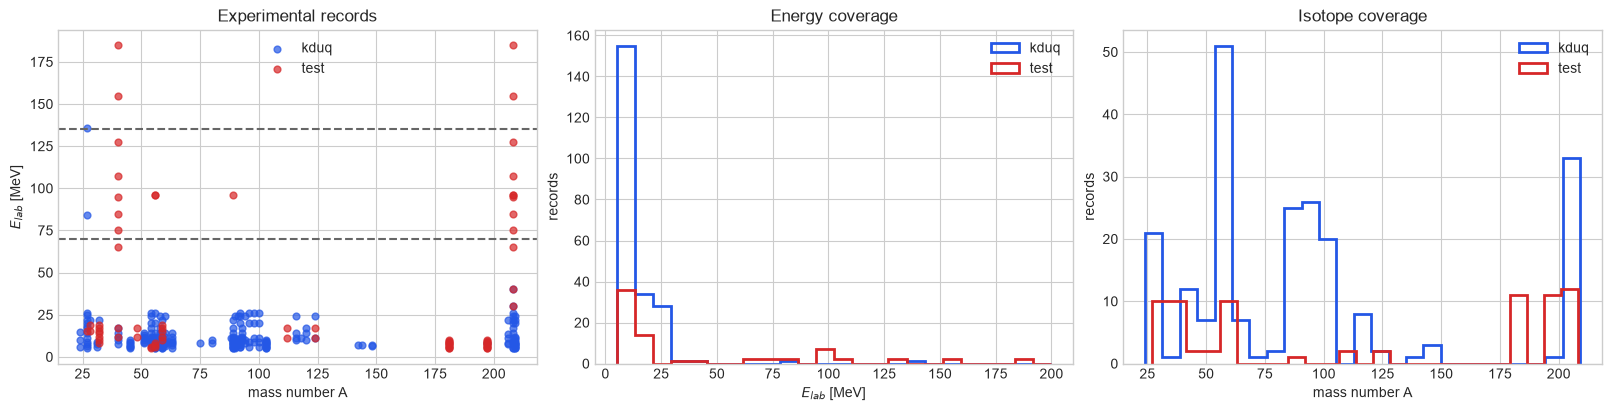

In [3]:
fig,axes=plt.subplots(1,3,figsize=(16,4),layout="constrained")
colors={"kduq":"#2457E6","test":"#D62728"}
for corpus,group in records.groupby("corpus"):
    axes[0].scatter(group.A,group.energy_MeV,s=24,alpha=.7,label=corpus,color=colors[corpus])
    axes[1].hist(group.energy_MeV,bins=np.linspace(5,200,25),histtype="step",lw=2,label=corpus,color=colors[corpus])
    axes[2].hist(group.A,bins=25,histtype="step",lw=2,label=corpus,color=colors[corpus])
for edge in (70,135): axes[0].axhline(edge,color="0.4",ls="--")
axes[0].set(xlabel="mass number A",ylabel=r"$E_{lab}$ [MeV]",title="Experimental records")
axes[1].set(xlabel=r"$E_{lab}$ [MeV]",ylabel="records",title="Energy coverage")
axes[2].set(xlabel="mass number A",ylabel="records",title="Isotope coverage")
for axis in axes: axis.legend()
plt.show()

## 2. Load the trusted hard-routed deployment

In [4]:
deployment=load_three_window_lrom(MODEL_ROOT,DISPLAY_ANGLES,runtime=runtime)
fom_problem=deployment.models[0].problem
manifest=pd.read_json(MODEL_ROOT/"training_manifest.json") if False else None
pd.DataFrame({
    "window":[0,1,2],"core low":deployment.energy_edges[:-1],"core high":deployment.energy_edges[1:],
    "basis size":[14]*3,"potential predictors":[20]*3,"ridge":[1e-14]*3,
    "partial-wave channels":[len(model.problem.channels) for model in deployment.models],
})

,window,core low,core high,basis size,potential predictors,ridge,partial-wave channels
0,0,5.0,70.0,14,20,1.000000e-14,73
1,1,70.0,135.0,14,20,1.000000e-14,73
2,2,135.0,200.0,14,20,1.000000e-14,73


## 3. Evaluate KD with the FOM and LROM at every experimental record

For each angular distribution, one union grid contains both the dense
display angles and every measured angle. This avoids interpolation when
computing emulator/FOM discrepancies at the data locations.

In [5]:
def normalization_profile(theory,observed,sigma,tau):
    weight=1/np.maximum(sigma,1e-30)**2
    delta=np.sum(theory*(observed-theory)*weight)/(1/tau**2+np.sum(theory**2*weight))
    chi2=np.sum(((observed-(1+delta)*theory)/sigma)**2)+(delta/tau)**2
    return float(delta),float(chi2)

predictions={}; metric_rows=[]
fom_seconds=lrom_seconds=0.0
for record in records.itertuples(index=False):
    group=points[points.record_id==record.record_id]
    measured=group.angle_cm_deg.to_numpy(float)
    angle_grid=np.unique(np.r_[DISPLAY_ANGLES,measured])
    sample={"A":int(record.A),"Z":int(record.Z),"E":float(record.energy_MeV)}
    tic=time.perf_counter(); fom=fom_problem.cross_section(sample,angle_grid); fom_seconds+=time.perf_counter()-tic
    tic=time.perf_counter(); lrom=deployment.models[deployment.route_energy(record.energy_MeV)].cross_section(sample,angle_grid); lrom_seconds+=time.perf_counter()-tic
    indices=np.searchsorted(angle_grid,measured)
    f,l=fom[indices],lrom[indices]
    floor=max(1e-12,1e-6*np.max(f))
    log_error=np.abs(np.log10(np.maximum(l,floor))-np.log10(np.maximum(f,floor)))
    active=f>floor
    relative=np.abs(l[active]-f[active])/f[active] if np.any(active) else np.asarray([np.nan])
    observed=group.cross_section_mb_sr.to_numpy(float)
    reported=group.point_error_mb_sr.to_numpy(float)
    sigma=np.sqrt(reported**2+(.02*observed)**2+(.001*observed.max())**2)
    tau=float(record.normalization_fraction)
    _,chi_fom=normalization_profile(f,observed,sigma,tau)
    _,chi_lrom=normalization_profile(l,observed,sigma,tau)
    window=deployment.route_energy(record.energy_MeV)
    metric_rows.append(dict(record_id=record.record_id,corpus=record.corpus,target=record.target,A=record.A,Z=record.Z,energy_MeV=record.energy_MeV,window=window,points=len(group),median_log10_error=np.median(log_error),p95_log10_error=np.quantile(log_error,.95),median_relative_error=np.nanmedian(relative),chi2_per_point_fom=chi_fom/len(group),chi2_per_point_lrom=chi_lrom/len(group)))
    predictions[record.record_id]=dict(group=group,angles=angle_grid,fom=fom,lrom=lrom)
metrics=pd.DataFrame(metric_rows)
print(f"evaluated {len(records)} records / {len(points)} data points")
print(f"FOM wall time {fom_seconds:.2f} s; LROM wall time {lrom_seconds:.2f} s; scalar speedup {fom_seconds/lrom_seconds:.1f}x")

evaluated 294 records / 8221 data points
FOM wall time 16.74 s; LROM wall time 0.70 s; scalar speedup 24.1x


In [6]:
metrics.groupby(["corpus","window"]).agg(
    records=("record_id","size"),
    median_log10_error=("median_log10_error","median"),
    p95_log10_error=("p95_log10_error",lambda x:np.quantile(x,.95)),
    median_relative_error=("median_relative_error","median"),
    median_chi2_FOM=("chi2_per_point_fom","median"),
    median_chi2_LROM=("chi2_per_point_lrom","median"),
)

records  median_log10_error  p95_log10_error  \
corpus window                                                 
kduq   0           219            0.000575         0.014357   
       1             1            0.000001         0.000004   
       2             1            0.000002         0.000003   
test   0            54            0.000750         0.067294   
       1            15            0.000004         0.000470   
       2             4            0.000013         0.000825   

               median_relative_error  median_chi2_FOM  median_chi2_LROM  
corpus window                                                            
kduq   0                    0.001326         6.166326          6.047815  
       1                    0.000003         6.233364          6.233323  
       2                    0.000006         4.975210          4.975053  
test   0                    0.001726        11.052289         12.174804  
       1                    0.000009         4.571637          4.571461  
       2                    0.000029         3.382097          3.381116

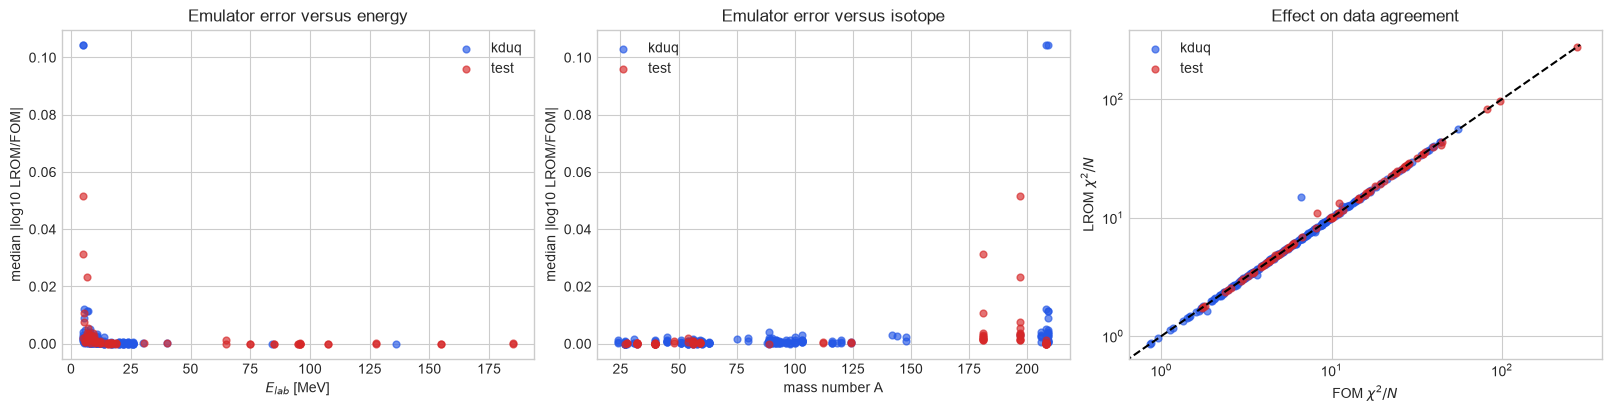

In [7]:
fig,axes=plt.subplots(1,3,figsize=(16,4),layout="constrained")
for corpus,color in colors.items():
    group=metrics[metrics.corpus==corpus]
    axes[0].scatter(group.energy_MeV,group.median_log10_error,s=24,alpha=.65,label=corpus,color=color)
    axes[1].scatter(group.A,group.median_log10_error,s=24,alpha=.65,label=corpus,color=color)
    axes[2].scatter(group.chi2_per_point_fom,group.chi2_per_point_lrom,s=24,alpha=.65,label=corpus,color=color)
axes[0].set(xlabel=r"$E_{lab}$ [MeV]",ylabel="median |log10 LROM/FOM|",title="Emulator error versus energy")
axes[1].set(xlabel="mass number A",ylabel="median |log10 LROM/FOM|",title="Emulator error versus isotope")
limit=max(axes[2].get_xlim()[1],axes[2].get_ylim()[1]); axes[2].plot([0,limit],[0,limit],color="black",ls="--")
axes[2].set(xscale="log",yscale="log",xlabel=r"FOM $\chi^2/N$",ylabel=r"LROM $\chi^2/N$",title="Effect on data agreement")
for axis in axes: axis.legend()
plt.show()

## 4. Plot every angular distribution

The following cell writes paginated PNG files containing every retained
record. This prevents a 40-page notebook output while still making the
complete audit easy to inspect. The first page and the worst emulator
cases are displayed inline.

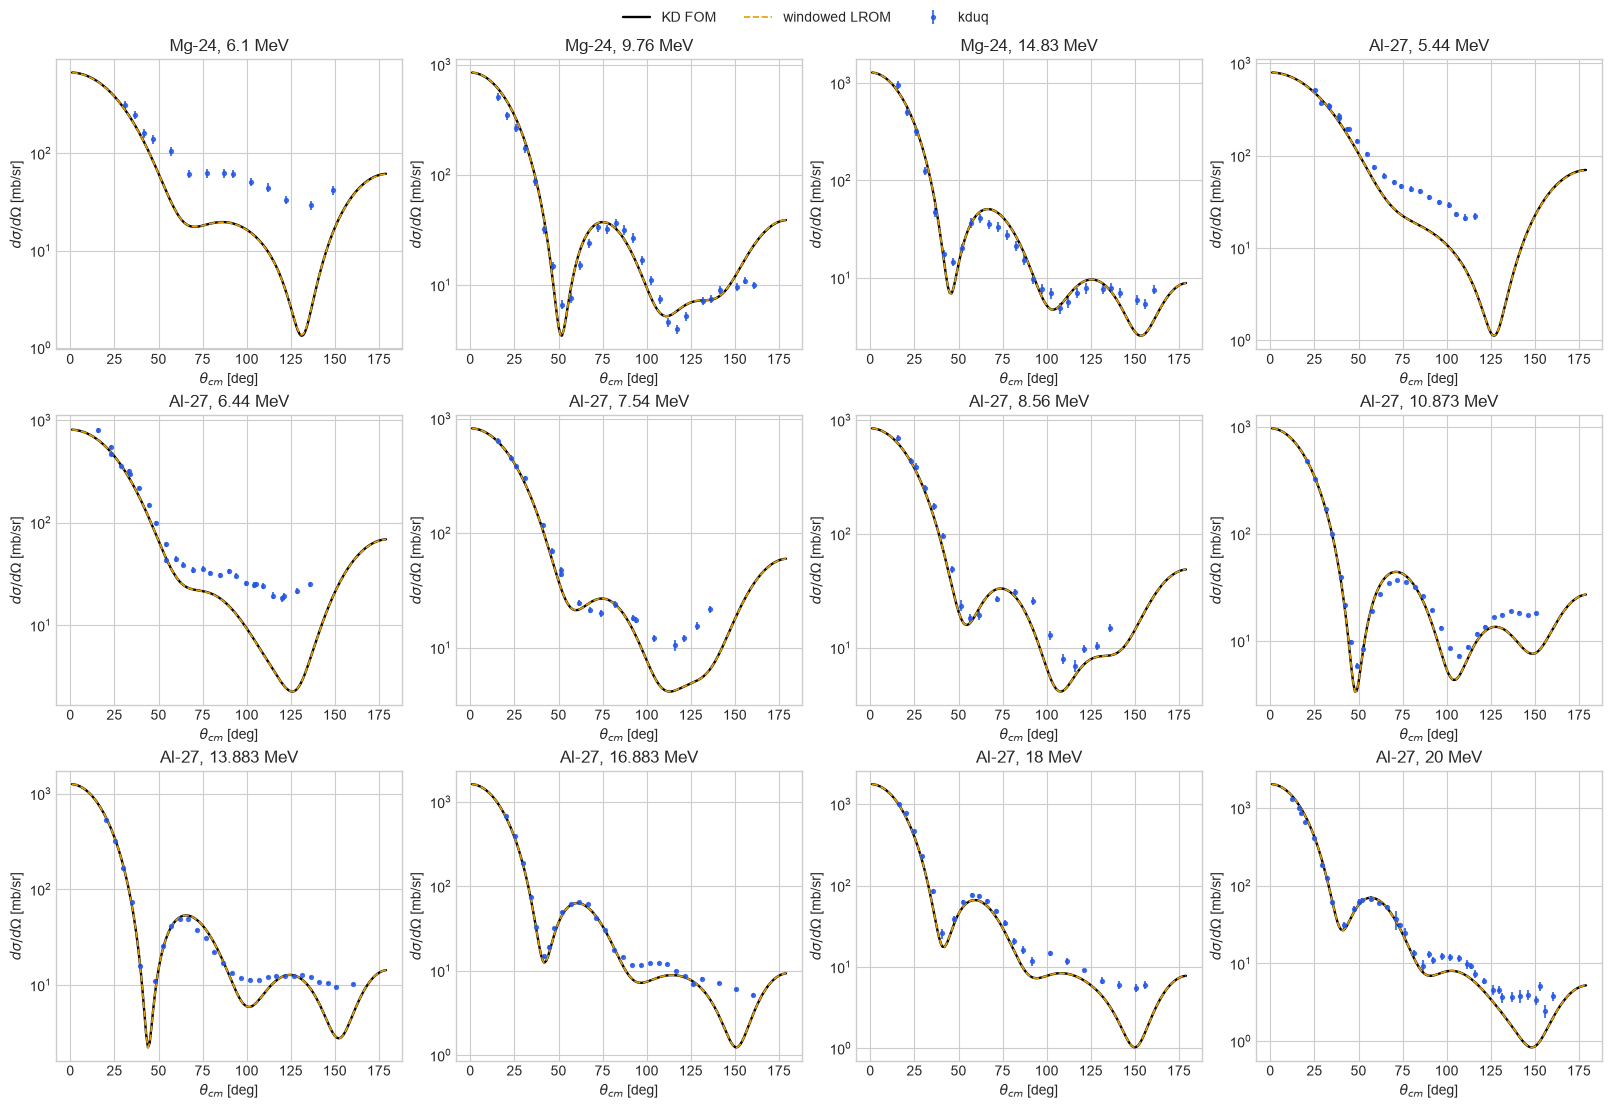

wrote 25 pages to C:\Users\Pablo\Documents\LROM\Scattering\CleanCode\artifacts\real_data_kd_overlays


In [8]:
ordered=records.sort_values(["corpus","A","Z","energy_MeV","record_id"])
page_size=12
page_paths=[]
for page,start in enumerate(range(0,len(ordered),page_size),1):
    subset=ordered.iloc[start:start+page_size]
    fig,axes=plt.subplots(3,4,figsize=(16,11),layout="constrained")
    for axis in axes.flat: axis.set_visible(False)
    for axis,record in zip(axes.flat,subset.itertuples(index=False)):
        axis.set_visible(True); item=predictions[record.record_id]; group=item["group"]
        axis.errorbar(group.angle_cm_deg,group.cross_section_mb_sr,yerr=group.point_error_mb_sr,fmt="o",ms=2.8,color=colors[record.corpus],alpha=.8,label=record.corpus)
        axis.semilogy(item["angles"],item["fom"],color="black",lw=1.7,label="KD FOM")
        axis.semilogy(item["angles"],item["lrom"],color="#E69F00",ls="--",lw=1.2,label="windowed LROM")
        axis.set(title=f"{record.target}, {record.energy_MeV:g} MeV",xlabel=r"$\theta_{cm}$ [deg]",ylabel=r"$d\sigma/d\Omega$ [mb/sr]")
    handles,labels=next(axis.get_legend_handles_labels() for axis in axes.flat if axis.get_visible())
    fig.legend(handles,labels,loc="outside upper center",ncol=3)
    path=OUTPUT/f"all_records_page_{page:02d}.png"; fig.savefig(path,dpi=140); page_paths.append(path)
    if page==1: plt.show()
    else: plt.close(fig)
print(f"wrote {len(page_paths)} pages to {OUTPUT}")

## 5. Worst LROM/FOM cases under a microscope

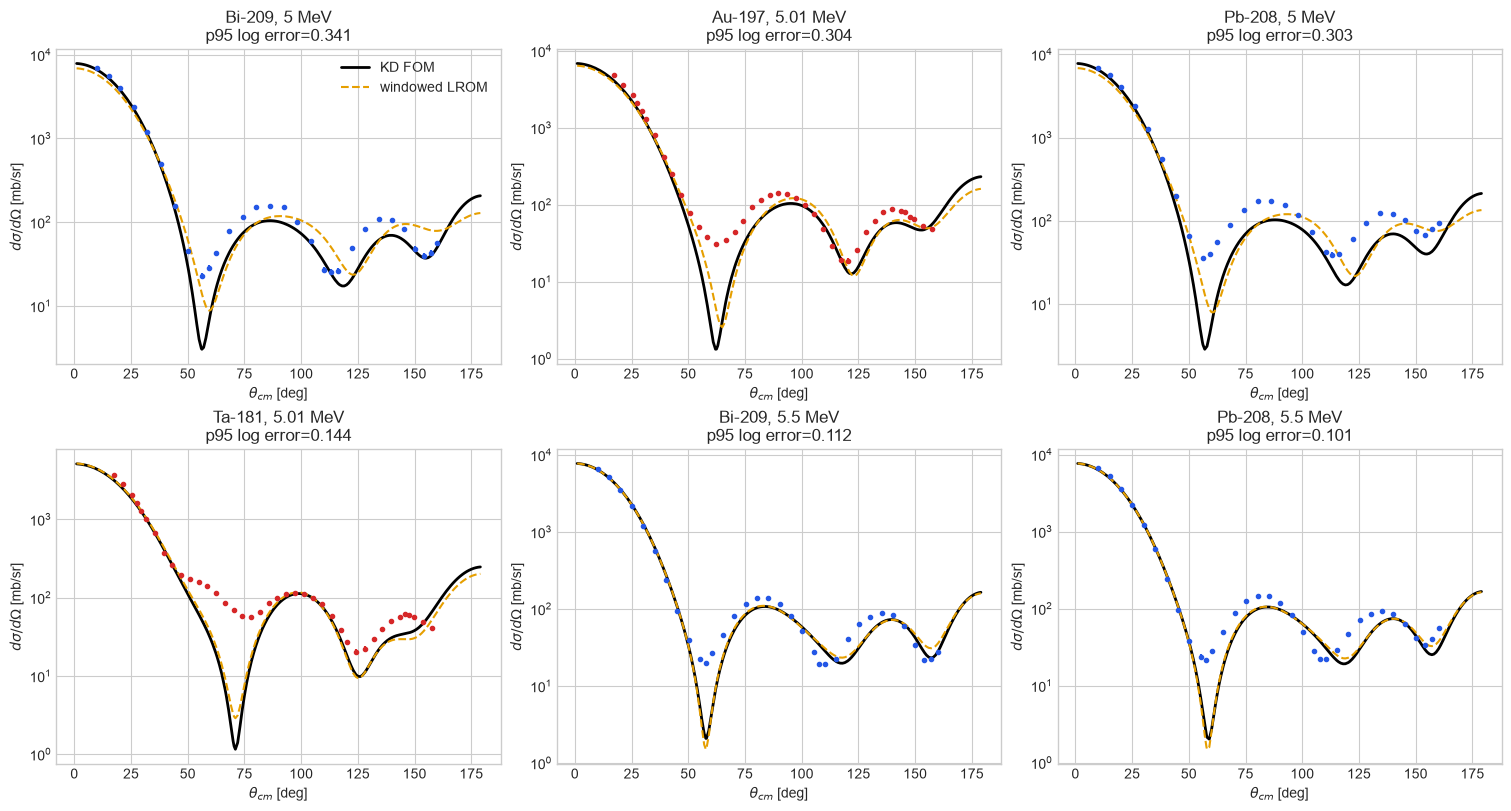

,corpus,target,energy_MeV,window,median_log10_error,p95_log10_error,median_relative_error,chi2_per_point_fom,chi2_per_point_lrom
206,kduq,Bi-209,5.00,0,0.104433,0.341137,0.229785,6.587852,15.059083
271,test,Au-197,5.01,0,0.051628,0.303808,0.126251,11.102837,13.333537
193,kduq,Pb-208,5.00,0,0.104454,0.303420,0.226229,14.762824,14.441718
260,test,Ta-181,5.01,0,0.031179,0.144134,0.073406,44.204974,41.388103
207,kduq,Bi-209,5.50,0,0.009039,0.111989,0.020595,5.892502,5.863212
194,kduq,Pb-208,5.50,0,0.012267,0.101105,0.028203,8.038804,7.528452


In [9]:
worst=metrics.nlargest(6,"p95_log10_error")
fig,axes=plt.subplots(2,3,figsize=(15,8),layout="constrained")
for axis,record in zip(axes.flat,worst.itertuples(index=False)):
    item=predictions[record.record_id]; group=item["group"]
    axis.errorbar(group.angle_cm_deg,group.cross_section_mb_sr,yerr=group.point_error_mb_sr,fmt="o",ms=3,color=colors[record.corpus])
    axis.semilogy(item["angles"],item["fom"],color="black",lw=2,label="KD FOM")
    axis.semilogy(item["angles"],item["lrom"],color="#E69F00",ls="--",label="windowed LROM")
    axis.set(title=f"{record.target}, {record.energy_MeV:g} MeV\np95 log error={record.p95_log10_error:.3g}",xlabel=r"$\theta_{cm}$ [deg]",ylabel=r"$d\sigma/d\Omega$ [mb/sr]")
axes.flat[0].legend(); plt.show()
worst[["corpus","target","energy_MeV","window","median_log10_error","p95_log10_error","median_relative_error","chi2_per_point_fom","chi2_per_point_lrom"]]

## 6. Batched deployment throughput and conditioning

Calibration asks for many cases at once. The router groups cases by
energy window and sends the stacked reduced solves to the configured
runtime. We also scan the maximum channel condition number for a
stratified subset; this is the online singularity diagnostic, distinct
from the offline design spectrum.

In [10]:
unique_cases=[{"A":int(r.A),"Z":int(r.Z),"E":float(r.energy_MeV)} for r in records.itertuples(index=False)]
deployment.partial_wave_s_matrices(unique_cases[:4])
tic=time.perf_counter(); plus,minus,wave_numbers=deployment.partial_wave_s_matrices(unique_cases); batch_seconds=time.perf_counter()-tic
print(f"{len(unique_cases)} routed cases in {1000*batch_seconds:.1f} ms = {len(unique_cases)/batch_seconds:.0f} cases/s ({runtime.name})")

subset_index=np.unique(np.linspace(0,len(records)-1,min(80,len(records)),dtype=int))
condition_rows=[]
for index in subset_index:
    record=records.iloc[index]; window=deployment.route_energy(record.energy_MeV); model=deployment.models[window]
    sample={"A":int(record.A),"Z":int(record.Z),"E":float(record.energy_MeV)}
    conditions=[model.predict(sample).condition_number(channel) for channel in model.problem.channels]
    condition_rows.append(dict(corpus=record.corpus,target=record.target,energy_MeV=record.energy_MeV,window=window,maximum_condition=max(conditions)))
condition=pd.DataFrame(condition_rows)
condition.groupby("window").maximum_condition.agg(["median",lambda x:np.quantile(x,.95),"max"])

294 routed cases in 131.0 ms = 2244 cases/s (numpy-cpu)


,median,<lambda_0>,max
window,,,
0,1.555146e+08,1.003305e+09,1.141494e+09
1,1.717061e+06,4.070951e+06,4.475794e+06
2,4.095177e+06,4.095177e+06,4.095177e+06


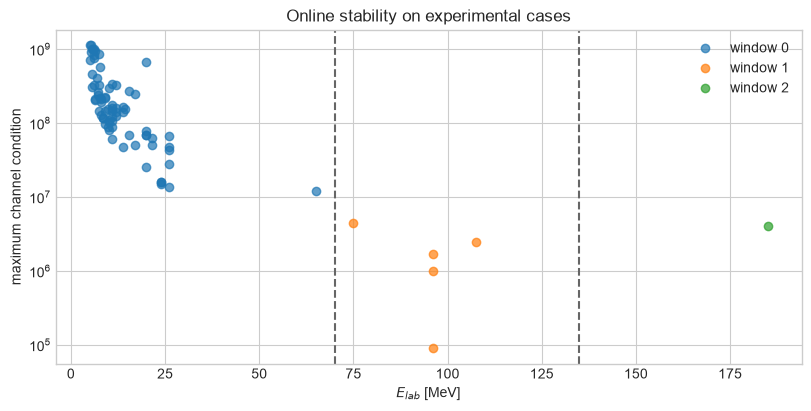

In [11]:
fig,ax=plt.subplots(figsize=(8,4),layout="constrained")
for window,group in condition.groupby("window"):
    ax.semilogy(group.energy_MeV,group.maximum_condition,"o",alpha=.7,label=f"window {window}")
for edge in (70,135): ax.axvline(edge,color="0.4",ls="--")
ax.set(xlabel=r"$E_{lab}$ [MeV]",ylabel="maximum channel condition",title="Online stability on experimental cases")
ax.legend(); plt.show()

# Conclusions and next checks

- KD/data disagreement is a property of the baseline optical model;
  LROM/FOM disagreement is emulator error. They must not be conflated.
- The KDUQ corpus is for fitting; the newer `test` corpus is held out.
- Hard routing evaluates one local model per energy, while overlapping
  training supports protect window boundaries.
- Production calibration should repeat these diagnostics over the full
  optical-parameter prior, not only at the central KD curve.
- If a worst case coincides with a large online condition number, add
  training support or revise that window before expanding the Bayesian
  calculation.